![earthkit-hydro-logo](https://github.com/ecmwf/logos/raw/refs/heads/main/logos/earthkit/earthkit-hydro-light.svg)

# Earthkit-hydro: Computing Accumulations Along River Networks

Tnis notebook will show a simple example of computing global and local accumulations along river networks.

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp
import earthkit.hydro as ekh

First, we load the relevant data needed for the notebook.

In [ ]:
# load an example precipitation dataset
da = ekd.from_source(
    "sample",
    "R06a.nc",
)[0].to_xarray()

# some nice custom plots styles
style = ekp.styles.Style(
    colors="Blues",
    levels=[0, 0.5, 1, 2, 5, 10, 50, 100, 500, 1000, 2000, 3000, 4000],
    extend="max",
)

# load the river network
network = ekh.river_network.load("efas", "5")

River network not found in cache (/var/folders/td/yqnxcqpx39dc855vwjtv5hj40000gn/T/tmps8xte4j__earthkit_hydro/1.1_60f3ec02b618c7fda7d71dc5219032531209e5b13663d65f7651d5370375fe15.joblib).
Loading river network from cache (/var/folders/td/yqnxcqpx39dc855vwjtv5hj40000gn/T/tmps8xte4j__earthkit_hydro/1.1_0dc8123bbf944ff1cb86f41bc7506e891baaa990666d836fc0cf2edd503916db.joblib).


There are two different categories of accumulations in earthkit-hydro.
1. full flow accumulations (global aggregation)
2. one-step neighbor accumulations (local aggregation).

## Global aggregation

Global aggregations from sources to sinks can computed via the `ekh.upstream` submodule, and aggregations from sinks to sources can be computed using the `ekh.downstream` submodule.

Many different aggregations are possible, namely `sum`, `min`, `max`, `mean`, `var`, `std`.

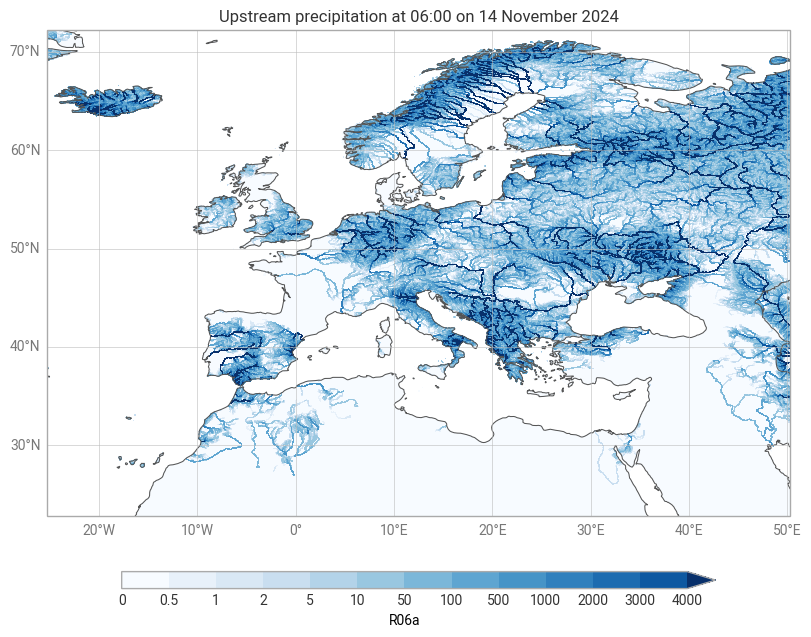

In [ ]:
upstream_sum = ekh.upstream.sum(network, da)

chart = ekp.Map()
chart.quickplot(upstream_sum, style=style)
chart.legend(label="{variable_name}")
chart.title("Upstream precipitation at {time:%H:%M on %-d %B %Y}")
chart.coastlines()
chart.gridlines()
chart.show()

## Local aggregation

Local aggregations can be computed using the `move` submodule, and the same metrics are available.

Below we show an example using `move.downstream` to find the number of gridcells draining to each point.

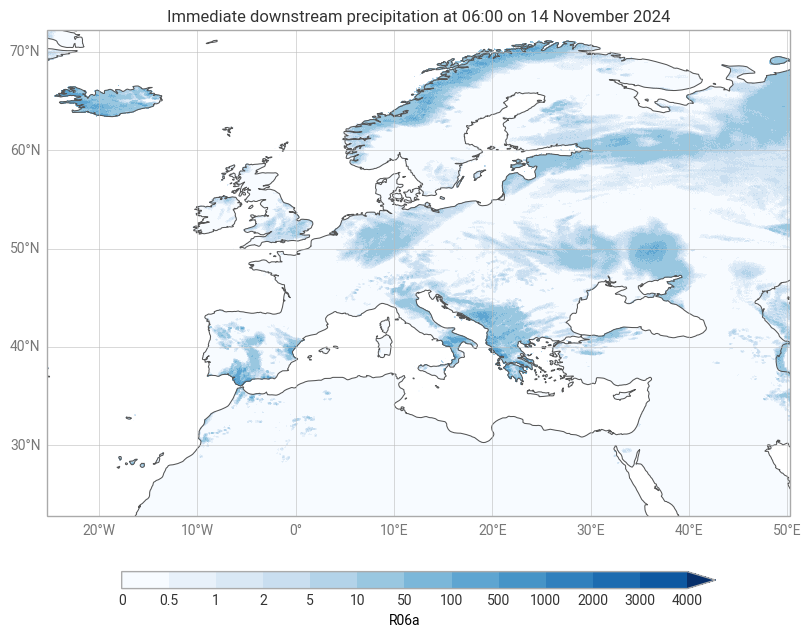

In [ ]:
move_downstream = ekh.move.downstream(network, da, metric="sum")

chart = ekp.Map()
chart.quickplot(move_downstream, style=style)
chart.legend(label="{variable_name}")
chart.title("Immediate downstream precipitation at {time:%H:%M on %-d %B %Y}")
chart.coastlines()
chart.gridlines()
chart.show()